LAB Lezione 8: Autoencoders

## Hands-on on anomaly detection:
### 1- Detecting heart arrhythmias using PCA

**Goal:** We want to create an anomaly detection model that can detect anomalous beats in ECG signal (heart arrhythmia), using PCA

We will use a public ECG database containing 22891 beats ( 22777 normal and 114 anomalies).

**Normal Beat**
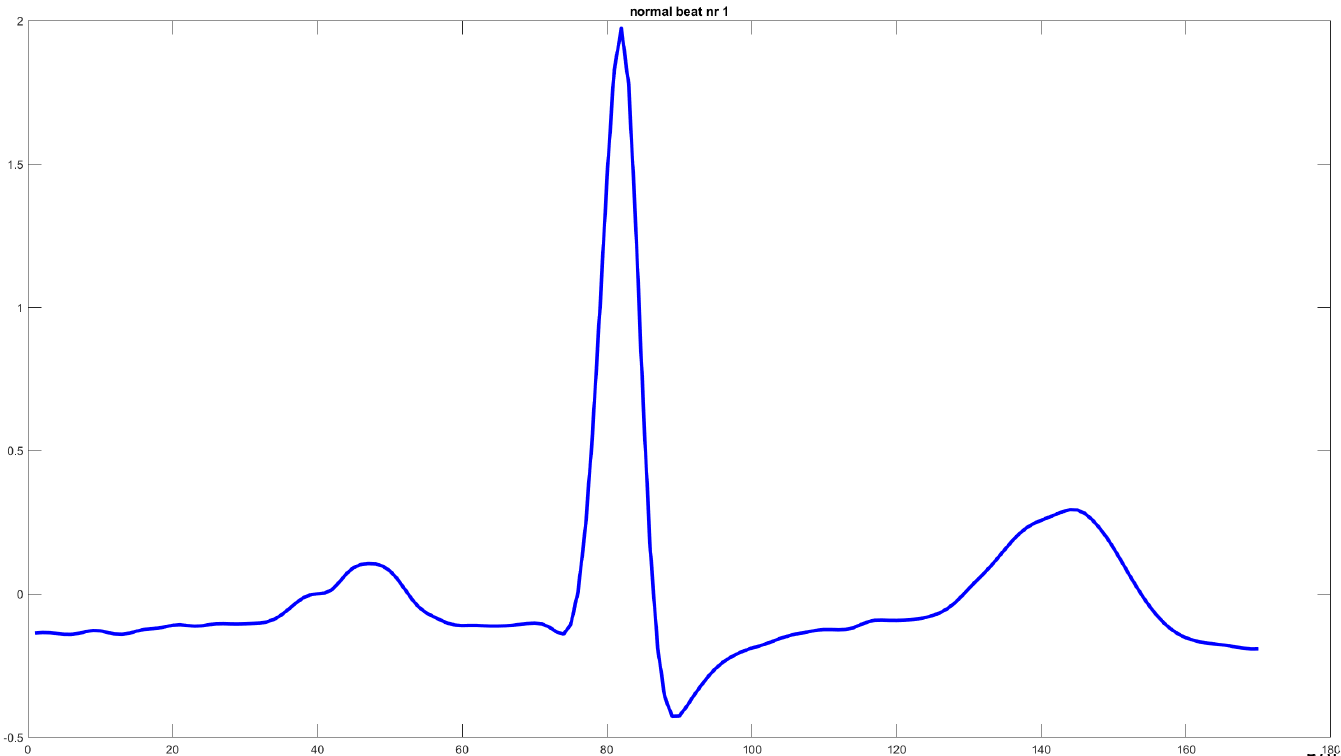

**Anomalous Beat**

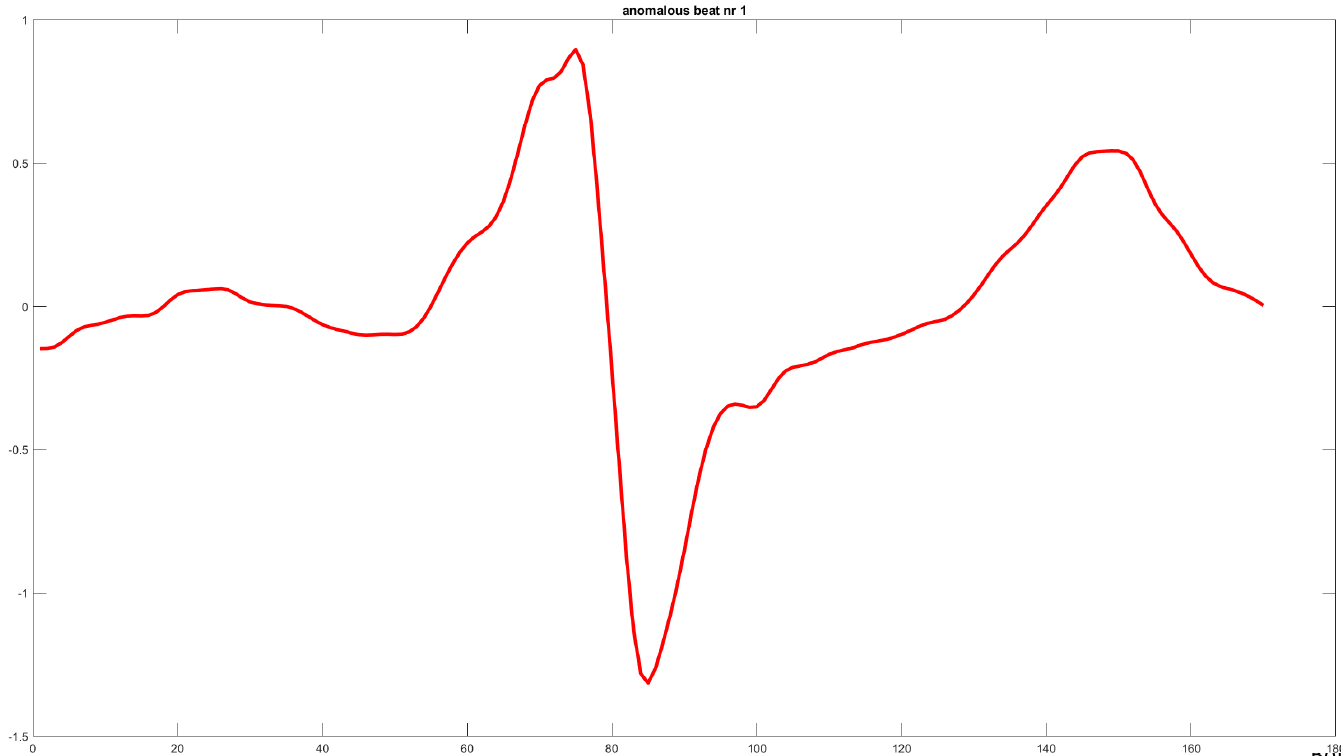

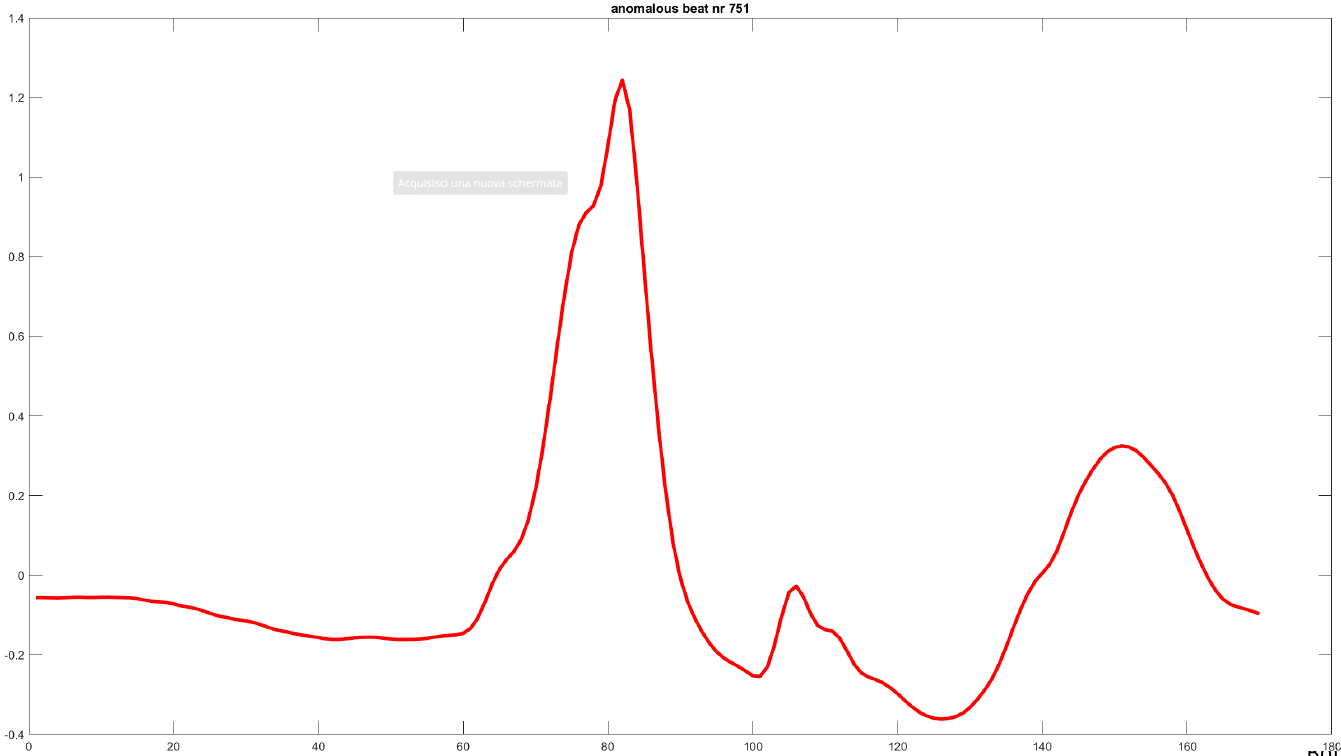

**Steps**

1.   Load the dataset. It is already divided into a training dataset and a testing dataset.
2.   Choose the number of principal components to use and train PCA on the training dataset (no labels).
3.   Calculate the reconstruction error for all testing data (Mean Absolute Error).
4.   Calculate the ROC curve and the AUC


PCA

/var/folders/x2/gw8lnpfn3rl_bq8qbsh1pblm0000gn/T/ipykernel_89261/2335201547.py:6: DeprecationWarning: numpy.core.fromnumeric is deprecated and has been renamed to numpy._core.fromnumeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.fromnumeric.argmax.
  from numpy.core.fromnumeric import argmax


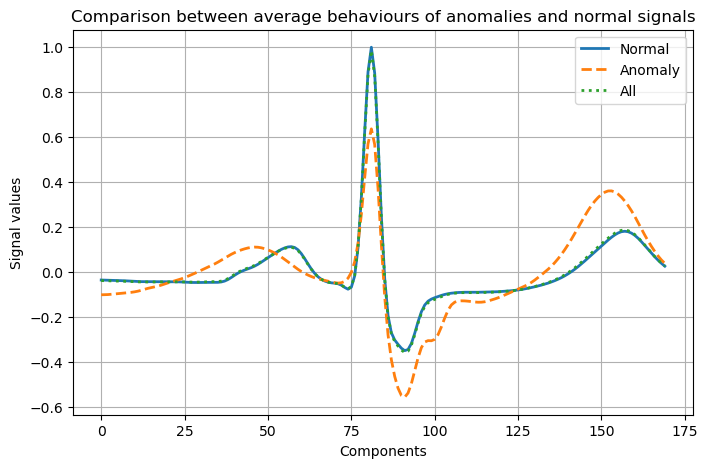

The error between the normal mean and the anomaly mean is: 0.08191883668078521
An example of error between the normal mean and a single normal signal is: 0.021064822601178312


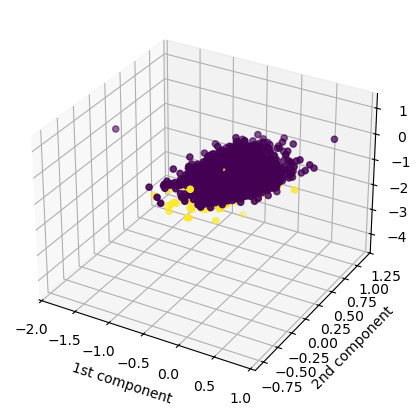

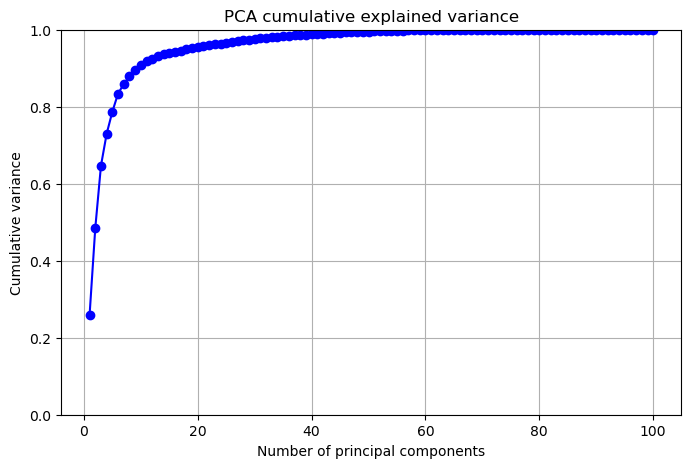

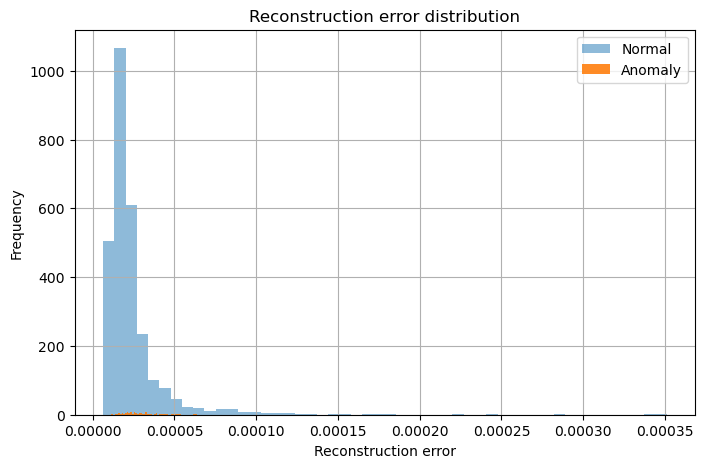

The AUC is 0.7226
The maximum value of th balanced accuracy is  0.2592963386727689  and the corresponding percentile is at  80.89999999999995


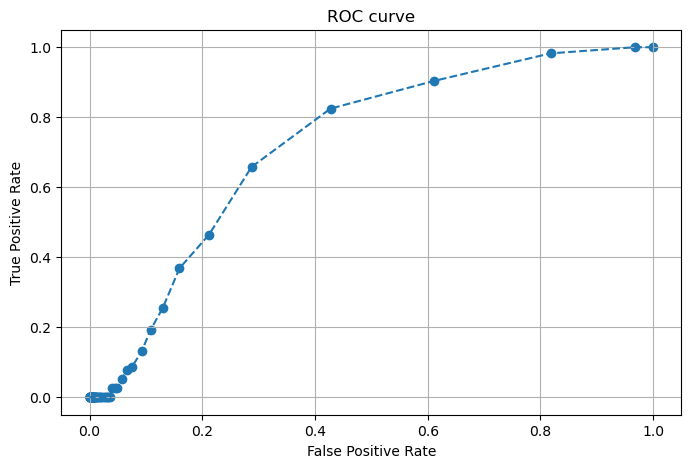

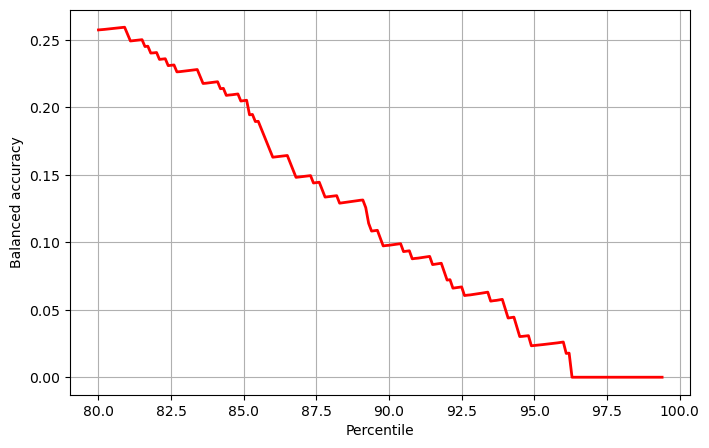

In [5]:
import sys

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from numpy.core.fromnumeric import argmax
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, auc, balanced_accuracy_score, mean_absolute_error


def anomaly_characterization(params, testing_data):
    """
    Such function builds up a comparison graph between average behaviours of anomalies and normal signals.

    :param params:
    :param testing_data:
    :return:
    """
    n_anomalies = params[0]
    n_samples = params[1]
    n_components = params[2]
    ## Create the pandas dataframe from the features
    df = pd.DataFrame(testing_data)
    ## Let's see how an anomaly appears:
    plt.figure(figsize=(8, 5))
    plt.grid(True)
    plt.title("Comparison between average behaviours of anomalies and normal signals")
    plt.plot(df.iloc[:n_samples - n_anomalies, :n_components].mean(numeric_only=True), lw=2, label='Normal')
    plt.plot(df.iloc[-1*n_anomalies:-1, :n_components].mean(numeric_only=True), lw=2, ls='--', label='Anomaly')
    plt.plot(df.iloc[:, :n_components].mean(numeric_only=True), lw=2, ls=':', label='All')
    plt.xlabel('Components')
    plt.ylabel('Signal values')
    plt.legend()
    plt.show()

    ## Error's order of magnitude:
    normal_mean = df.iloc[:n_samples - n_anomalies, :n_components].mean(numeric_only=True).to_numpy()
    anomaly_mean = df.iloc[-1*n_anomalies:-1, :n_components].mean(numeric_only=True).to_numpy()
    normal = testing_data[4]

    error_among_normal_and_anomaly = np.mean(np.abs(anomaly_mean - normal_mean), axis=0)
    error_among_normal_and_normal = np.mean(np.abs(normal - normal_mean), axis=0)
    print("The error between the normal mean and the anomaly mean is:", error_among_normal_and_anomaly)
    print("An example of error between the normal mean and a single normal signal is:", error_among_normal_and_normal)



def first_three_components_plot(y, labels):
    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter([row[0] for row in y], [row[1] for row in y], [row[2] for row in y], c=labels)
    #ax.scatter([row[0] for row in y], [row[1] for row in y], [0 for row in y], c=labels)

    ax.set_xlabel('1st component')
    ax.set_ylabel('2nd component')
    ax.set_zlabel('3rd component')
    plt.show()



def cumulative_variance_graph(n_components, cumulative_variance):
    ## Plot the explained variance
    plt.figure(figsize=(8, 5))
    plt.grid(True)
    plt.plot(range(1, n_components + 1), cumulative_variance, marker='o', linestyle='-', color='b', label='Cumulative variance')
    plt.title("PCA cumulative explained variance")
    plt.xlabel("Number of principal components")
    plt.ylabel("Cumulative variance")
    plt.ylim(0,1)
    plt.show()



def reconstruction_error_distribution(reconstruction_error, labels):
    plt.figure(figsize=(8, 5))
    plt.title("Reconstruction error distribution")
    plt.grid(True)
    plt.hist(reconstruction_error[labels == 0], bins=50, alpha=0.5, label='Normal')
    plt.hist(reconstruction_error[labels == 1], bins=50, alpha=0.9, label='Anomaly')
    plt.xlabel('Reconstruction error')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()



def plot_ROC(RE, labels):
    """
    This function plots the ROC curve
    :param RE: the reconstruction errors
    :param labels: the true labels
    :return:
    """
    ## gammas contains different thresholds used to discriminate anomalies from normal data
    gammas = np.linspace(np.min(RE), np.max(RE), 100)

    X, Y = [], []

    for gamma in gammas:
        '''
        Evaluate TPR and FPR for every threshold gamma
        '''
        anomalies = RE > gamma

        TN, FP, FN, TP = confusion_matrix(labels, anomalies, labels=[0, 1]).ravel()

        sensitivity = TP / (TP + FN)
        specificity = FP / (TN + FP)

        Y.append(sensitivity)
        X.append(specificity)

    ## Add 0 threshold (used to plot a nicer curve only)
    X.append(0)
    Y.append(0)

    ## Plot the ROC curve and save the image
    plt.rcParams['figure.figsize'] = [8, 5]
    plt.figure(figsize=(8, 5))
    plt.grid(True)
    plt.plot(X, Y, linestyle='--')
    plt.title('ROC curve')
    plt.scatter(X, Y)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.xlim(-0.05, 1.05)
    plt.ylim(-0.05, 1.05)
    plt.savefig("ROC.png")

    return X, Y



def balance_accuracy_plot(reconstruction_error, labels):
    percentile = np.arange(80, 99.5, 0.1)
    balanced_accuracy = []
    for p in percentile:
        threshold = np.percentile(reconstruction_error, p)  # Adjust percentile as needed
        anomalies_indices = np.where(reconstruction_error > threshold)[0]

        normal = 0
        fraud = 0
        for i in anomalies_indices:
            if labels[i]:
                normal = normal + 1
            else:
                fraud = fraud + 1

        anomalies = reconstruction_error > threshold
        TN, FP, FN, TP = confusion_matrix(labels, anomalies, labels=[0, 1]).ravel()

        precision = TP / (FP + TP)
        recall = TP / (TP + FN)

        balanced_accuracy.append(0.5*(precision + recall))

    p_max = argmax(balanced_accuracy)
    print('The maximum value of th balanced accuracy is ', max(balanced_accuracy), ' and the corresponding percentile is at ', percentile[p_max] )
    plt.figure(figsize=(8,5))
    plt.grid(True)
    plt.plot(percentile, balanced_accuracy, lw=2, c='r')
    plt.xlabel('Percentile')
    plt.ylabel('Balanced accuracy')
    plt.show()



def main():

    ## The following dictionary contains: the number of anomalies in the test dataset (the training dataset cannot and should not contain any),
    ## the number of samples, the number of components for each element in the test dataset, and the corresponding file.

    dataset_dict = {'Ising': [129, 2649, 25,'SpinsAD.npz'],
                    'HeartBeats': [114, 2891, 170,'HeartBeatsAD.npz']}

    ## TODO: Repeat the same exercise for the heartbeats dataset.
    system_name = 'HeartBeats'

    ## Load ECG dataset (contains values of the signals)
    raw_data = np.load(dataset_dict[system_name][-1])
    training_data, testing_data, labels = raw_data["training_data"], raw_data["testing_data"], raw_data["labels"]

    anomaly_characterization(params=dataset_dict[system_name], testing_data=testing_data)

    ## TODO: Define a PCA model using a suitable number of components (max_n_components > n_components > 0)
    n_components = 100
    pca = PCA(n_components)

    ## TODO: fit the model using training data
    pca.fit(training_data)

    ## TODO: apply PCA on testing data reduced_input = PCA(data)
    y = pca.transform(testing_data)

    ## Let's have a look at the graphical representation of the first three components of the reduced input.
    ## Is such dimensionality reduction already enough to distinguish anomalies?
    if n_components >= 3:
        first_three_components_plot(y, labels)

    ## Calculate explained variance and cumulative explained variance
    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance_ratio)

    ## Let's see how the cumulative variance evolves increasing the number of principal components:
    cumulative_variance_graph(n_components, cumulative_variance)

    ## TODO: apply the inverse transformation to reconstruct the data reconstructed_input = inverse_PCA(reduced_input)
    reconstructed_input = pca.inverse_transform(y)

    ## TODO: evaluate the Reconstruction Error (Mean Absolute Error)
    #reconstruction_error = mean_absolute_error(reconstructed_input, testing_data)
    reconstruction_error = np.mean(np.abs(reconstructed_input - testing_data), axis=1)
    ## Let's plot the reconstruction error distribution:
    reconstruction_error_distribution(reconstruction_error, labels)

    ## Let's plot the ROC curve:
    X, Y = plot_ROC(reconstruction_error, labels)
    print("The AUC is {:.4f}".format(auc(X, Y)))

    ## Plot the balance accuracy and the threshold at which its maximum value corresponds.
    balance_accuracy_plot(reconstruction_error, labels)



if __name__ == "__main__":
    main()


Autoencoder

The AUC is 0.9910


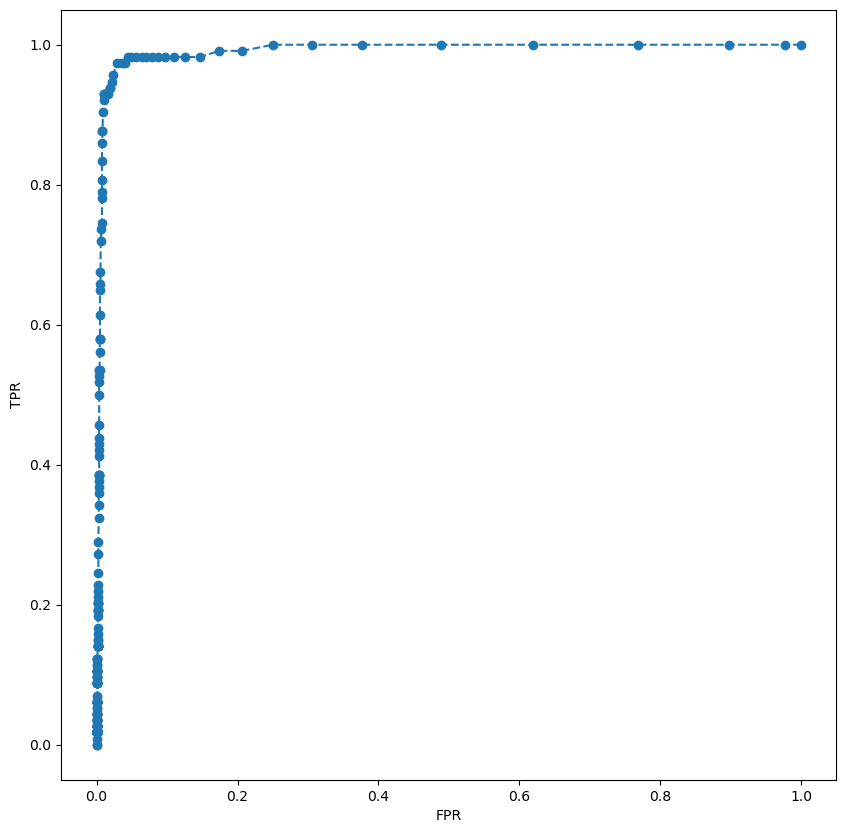

In [7]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import confusion_matrix, auc


def plot_ROC(RE, labels):
    """
    This function plots the ROC curve
    :param RE: the reconstruction errors
    :param labels: the true labels
    :return:
    """
    # gammas contains different thresholds used to discriminate anomalies from normal data
    gammas = np.linspace(torch.min(RE.detach()), torch.max(RE.detach()), 500)

    X, Y = [], []

    for gamma in gammas:
        '''
        Evaluate TPR and FPR for every threshold gamma
        '''
        anomalies = RE > gamma

        TN, FP, FN, TP = confusion_matrix(labels, anomalies).ravel()

        TPR = TP/(TP+FN)
        FPR = FP/(FP+TN)

        Y.append(TPR)
        X.append(FPR)

    # Add 0 threshold (used to plot a nicer curve only)
    X.append(0)
    Y.append(0)

    plt.rcParams['figure.figsize'] = [10, 10]

    plt.xlabel("FPR")
    plt.ylabel("TPR")

    plt.plot(X, Y, linestyle='--')
    plt.scatter(X, Y)
    plt.xlim(-0.05, 1.05)
    plt.ylim(-0.05, 1.05)
    plt.savefig("ROC.png")

    return X, Y

class Autoencoder(nn.Module):
    def __init__(self, input_size):
        super(Autoencoder, self).__init__()

        # TODO: define the model (autoencoder)
        #qui i primi 3 hidden layer sono encoder e gli altri decoder
        '''self.hidden_layer1 = nn.Linear(input_size,40)
        self.hidden_layer2 = nn.Linear(40,20)
        self.hidden_layer3 = nn.Linear(20,10)
        self.hidden_layer4 = nn.Linear(10,20)
        self.hidden_layer5 = nn.Linear(20,40)
        self.output_layer = nn.Linear(40,input_size)
        '''
        # This is the encoder (compress the information)
        self.encoder = torch.nn.Linear(input_size,20)
        # This is the decoder (reconstruct the compressed information)
        self.decoder = torch.nn.Linear(20, input_size)

        # TODO: define the optimizer
        self.optimizer = torch.optim.Adam(self.parameters(), lr=0.001)
        # TODO: define the loss (MSE)
        self.criterion = torch.nn.MSELoss()

    def encode(self, x):
        return self.encoder(x)

    def decode(self, x):
        return self.decoder(x)

    def forward(self, x):
        x = self.encode(x)
        x = self.decode(x)
        return x

    def train_step(self, inputs):
        # TODO: define the training step
        # zero the parameter gradients
        self.optimizer.zero_grad()

        # forward + backward + optimize
        outputs = self.forward(inputs)
        loss = self.criterion(inputs, outputs)
        loss.backward()
        self.optimizer.step()

        return loss.item()

def main():

    # Load ECG dataset (contains values of the signals)
    raw_data = np.load('HeartBeatsAD.npz')

    training_data, testing_data, labels = raw_data["training_data"], raw_data["testing_data"], raw_data["labels"]

    # Convert to Tensors
    training_data = torch.tensor(training_data, dtype=torch.float32)
    test_inputs = torch.tensor(testing_data, dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.float32)

    # Get the number of input feature
    n_features = training_data.shape[1]

    # TODO: Create a pytorch dataset
    loader_train = DataLoader(dataset=training_data[:int(n_features * 0.8)], batch_size=1, shuffle=True)

    # TODO: Define the autoencoder
    autoencoder_model = Autoencoder(input_size=n_features)

    # Train the autoencoder on normal data only
    n_epochs = 4
    for epoch in range(n_epochs):
        for input_data in loader_train:
            # TODO: train the model
            loss = autoencoder_model.train_step(input_data)

    with torch.no_grad():
        reconstructed_input = autoencoder_model(test_inputs)

    # TODO: evaluate the reconstruction error "recostructionError" (use torch)
    recostructionError = torch.mean((reconstructed_input - test_inputs)**2, dim=1)

    X, Y = plot_ROC(recostructionError, labels)

    print("The AUC is {:.4f}".format(auc(X, Y)))

if __name__ == "__main__": main()